In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN

can_log_path='logs/1_2018 Holden Astra/driving/1_driving_CAN_continuous.log'

# The CAN log format: (timestamp) can0 ID#Payload
df_can = pd.read_csv(can_log_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])

# Split the raw_frame into ID and Payload
frame_parts = df_can['raw_frame'].str.split('#', expand=True)
df_can['id'] = frame_parts[0]
df_can['payload'] = frame_parts[1]

# remove brackets from timestamp 
df_can['timestamp'] = df_can['timestamp'].str.strip('()').astype(float).astype(int)

print(df_can.shape,df_can.head())


(3837943, 5)     timestamp   bus             raw_frame   id           payload
0  1731919520  can0          1A6#44000000  1A6          44000000
1  1731919520  can0  0C5#40010CD200000000  0C5  40010CD200000000
2  1731919520  can0  0C9#840B6F2A000010FF  0C9  840B6F2A000010FF
3  1731919520  can0    0D1#00000000000000  0D1    00000000000000
4  1731919520  can0              0D3#2C24  0D3              2C24


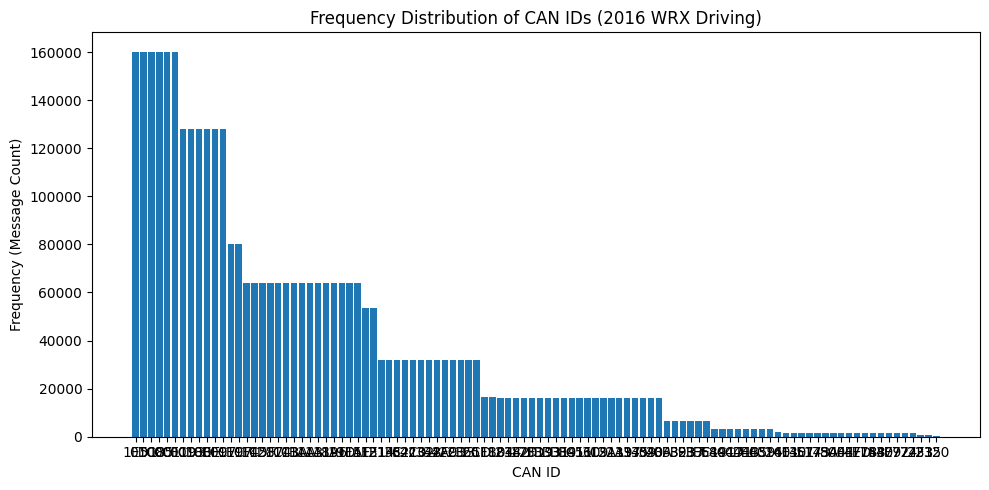

In [2]:
id_counts = df_can['id'].value_counts()
id_counts_sorted = id_counts.sort_values(ascending=False)

plt.figure(figsize=(10, 5))  

plt.bar(id_counts_sorted.index, id_counts_sorted.values)
plt.title('Frequency Distribution of CAN IDs (2016 WRX Driving)')
plt.xlabel('CAN ID')
plt.ylabel('Frequency (Message Count)')
plt.tight_layout()
plt.show()

Clusters for ID 0D3 (After Mask):
[  0   0   1 ... 496 496 496]
Unique clusters found: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 

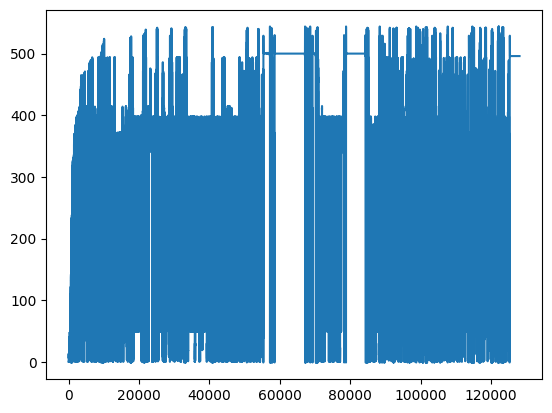

In [8]:

##Mask the checksum and counter (the first 2 bytes)
mask = int('FFFFFFFFFFFFFFFFF', 16) 

target_id = '0D3'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    payload_int = int(hex_str[:16], 16)
    
    # Apply the mask to remove the counter
    masked_int = payload_int & mask
    # Convert the *masked* int back to a binary string
    binary_str = bin(masked_int)[2:].zfill(64)
    
    bit_vector = [int(bit) for bit in binary_str]
    # if hex(masked_int) != prev_hex:
    #     print(hex(masked_int))
    #     # print(all_payloads_timestamps[i])
        
    X_list.append(bit_vector)
    prev_hex=hex(masked_int)
    
X = np.array(X_list)

db = DBSCAN(eps=0.01, min_samples=20, metric='hamming')
clusters = db.fit_predict(X)

print(f"Clusters for ID {target_id} (After Mask):")
print(clusters)
print(f"Unique clusters found: {np.unique(clusters)}")

plt.plot(clusters)

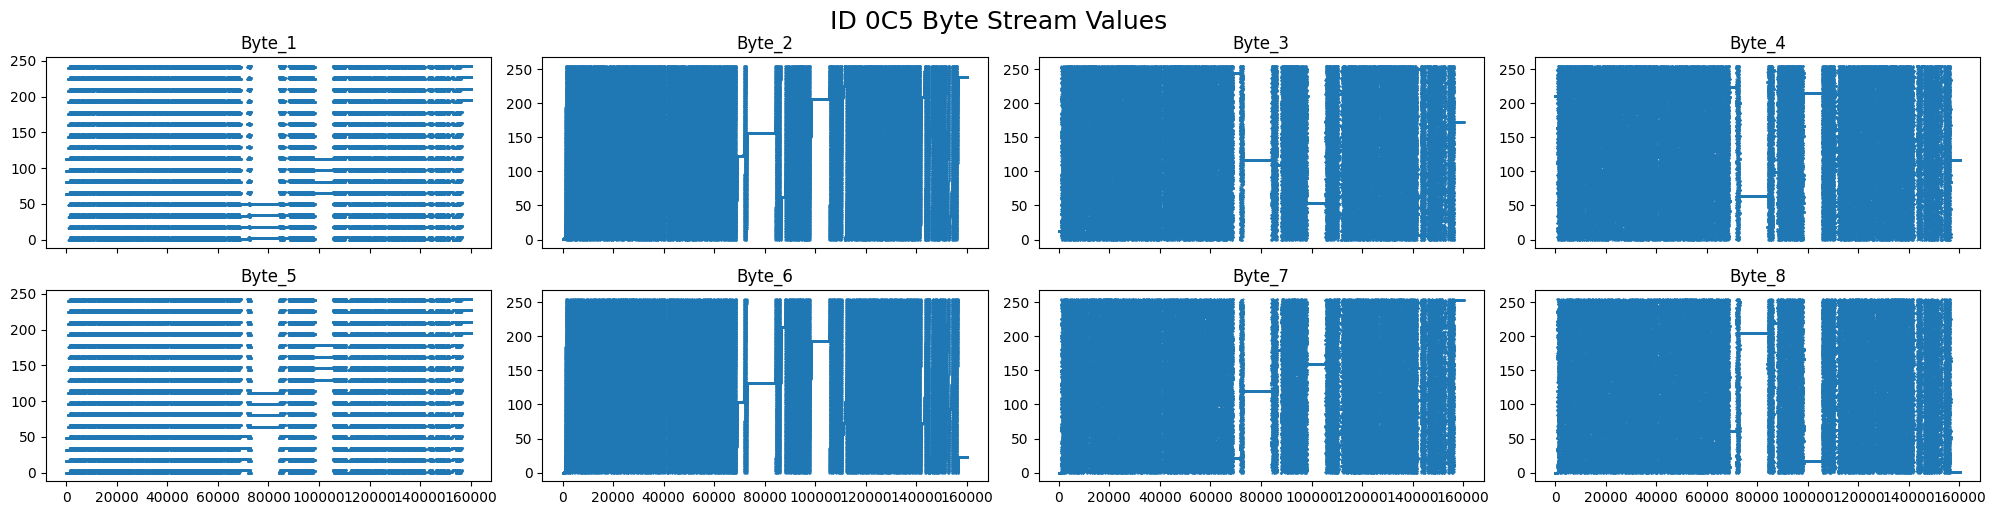

In [11]:
target_id = '0C5'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    # payload_int = int(hex_str[:16], 16)
    byte_array=[int(hex_str[i:i+2],16) for i in range(0,len(hex_str),2)]
    X_list.append(byte_array)
    while len(byte_array) < 8:
        byte_array.append(0)
byte_data = np.array(X_list)

df_bytes = pd.DataFrame(byte_data, columns=[f'Byte_{i+1}' for i in range(8)])
df_bytes.tail()
# Setup figure for plotting all 8 bytes
fig, axes = plt.subplots(2, 4, figsize=(20, 5), sharex=True)
axes = axes.flatten()

# Loop through each byte stream and plot the raw integer value
for byte_index, byte_name in enumerate(df_bytes.columns):
    byte_stream = df_bytes[byte_name].values
    
    ax = axes[byte_index]
    
    # Plot the raw integer value over the chronological frame index
    ax.plot(byte_stream, marker='.', linestyle='-', markersize=1, linewidth=0)
    
    # Set Y-axis to the full possible range for clear comparison
    # ax.set_ylim(-5, 260) 
    ax.set_title(f"{byte_name}")

plt.tight_layout()
plt.suptitle(f" ID {target_id} Byte Stream Values", y=1.02, fontsize=18)
plt.show()

Clusters for ID 152 (After Mask):
[0 0 0 ... 0 0 0]
Unique clusters found: [0 1]


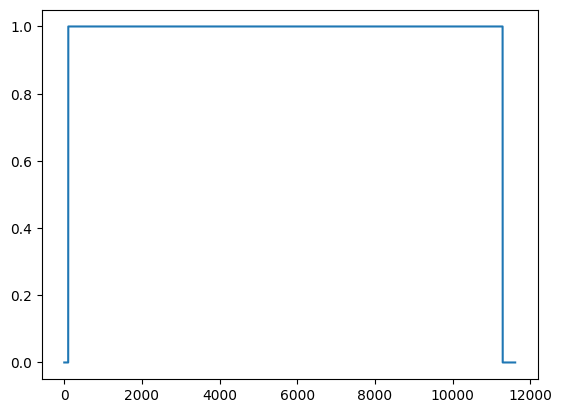

In [24]:

##Mask the checksum and counter (the first 2 bytes)
mask = int('00000000000000FF', 16) 

target_id = '152'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    payload_int = int(hex_str[:16], 16)
    
    # Apply the mask to remove the counter
    masked_int = payload_int & mask
    # Convert the *masked* int back to a binary string
    binary_str = bin(masked_int)[2:].zfill(64)
    
    bit_vector = [int(bit) for bit in binary_str]
#     if hex(masked_int) != prev_hex:
#         print(hex(masked_int))
#         print(all_payloads_timestamps[i])
        
    X_list.append(bit_vector)
    prev_hex=hex(masked_int)
    
X = np.array(X_list)

db = DBSCAN(eps=0.01, min_samples=20, metric='hamming')
clusters = db.fit_predict(X)

print(f"Clusters for ID {target_id} (After Mask):")
print(clusters)
print(f"Unique clusters found: {np.unique(clusters)}")

plt.plot(clusters)

Payload: FF020000, Value: 767, Speed: 43.14 km/h
Time stamp: 1498258985
Payload: FE020080, Value: 766, Speed: 43.09 km/h
Time stamp: 1498258985
Payload: FE020080, Value: 766, Speed: 43.09 km/h
Time stamp: 1498258985
Payload: FE020080, Value: 766, Speed: 43.09 km/h
Time stamp: 1498258985
Payload: FD020080, Value: 765, Speed: 43.03 km/h
Time stamp: 1498258985
Payload: FD020080, Value: 765, Speed: 43.03 km/h
Time stamp: 1498258986
Payload: FD020080, Value: 765, Speed: 43.03 km/h
Time stamp: 1498258986
Payload: FC020000, Value: 764, Speed: 42.98 km/h
Time stamp: 1498258986
Payload: FC020000, Value: 764, Speed: 42.98 km/h
Time stamp: 1498258986
Payload: FB020080, Value: 763, Speed: 42.92 km/h
Time stamp: 1498258986
Payload: FB020080, Value: 763, Speed: 42.92 km/h
Time stamp: 1498258986
Payload: FB020080, Value: 763, Speed: 42.92 km/h
Time stamp: 1498258986
Payload: FB020080, Value: 763, Speed: 42.92 km/h
Time stamp: 1498258986
Payload: FB020080, Value: 763, Speed: 42.92 km/h
Time stamp: 149

Text(0, 0.5, 'Speed km/hr')

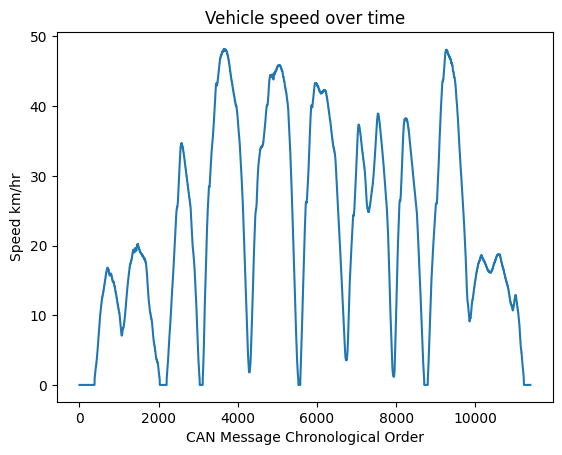

In [49]:
target_id = '0D1'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
speeds=[]
        
for i,payload_hex in enumerate(all_payloads_hex):
    # Get the first 2 bytes (4 hex chars)
    hex_b1b2 = payload_hex[0:4]

    # Ensure we have enough data to decode
    if len(hex_b1b2) == 4:
        
        # 1. Convert the hex string '0F04' to raw bytes b'\x0f\x04'
        raw_bytes = bytes.fromhex(hex_b1b2)
        
        # 2. Convert the raw bytes to an integer,
        #    specifying 'little' endianness.
        #    This automatically handles the (B2 * 256) + B1 logic.
        int_value = int.from_bytes(raw_bytes, 'little')

        speed_kmh = int_value * 0.05625
        speeds.append(speed_kmh)
        if len(speeds)>6000 and len(speeds)<6020:
            print(f"Payload: {payload_hex}, Value: {int_value}, Speed: {speed_kmh:.2f} km/h")
            print(f"Time stamp: {all_payloads_timestamps[i]}")

plt.plot(speeds)
plt.title('Vehicle speed over time')
plt.xlabel('CAN Message Chronological Order')
plt.ylabel('Speed km/hr')

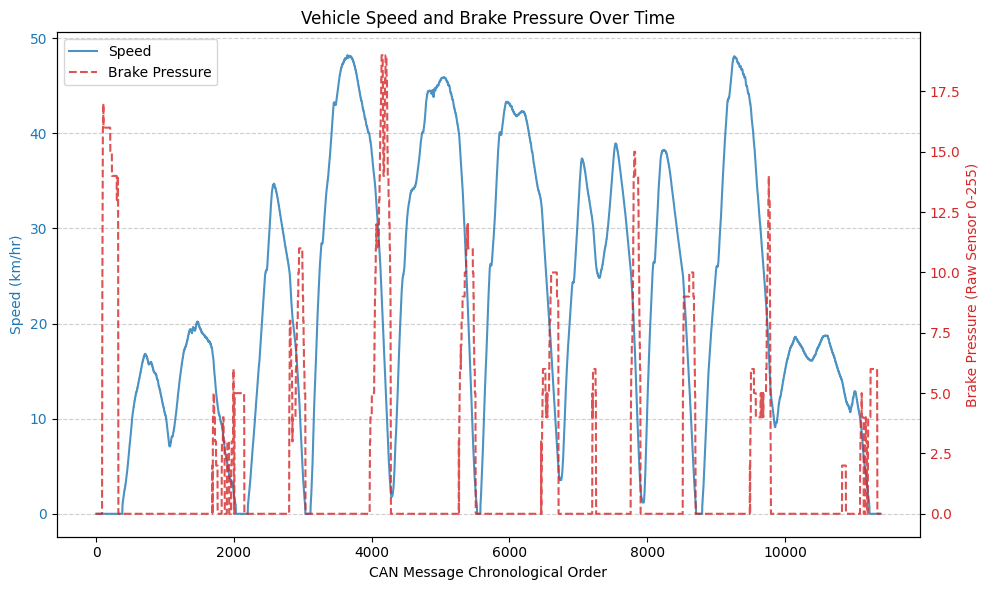

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure df_can and target_id are defined in your environment
# target_id = '0D1'
# all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()

speeds = []
brake_pressures = [] # New list for brake data
        
for payload_hex in all_payloads_hex:
    # --- Speed (Bytes 1-2) ---
    hex_b1b2 = payload_hex[0:4]
    if len(hex_b1b2) == 4:
        try:
            # 1. Convert the hex string to raw bytes
            raw_bytes = bytes.fromhex(hex_b1b2)
            # 2. Convert the raw bytes to an integer (little-endian)
            int_value = int.from_bytes(raw_bytes, 'little')
            speed_kmh = int_value * 0.05625
            speeds.append(speed_kmh)
        except (ValueError, TypeError):
            speeds.append(np.nan) # Use np.nan for invalid data
    else:
        speeds.append(np.nan) # Keep lists aligned

    # --- Brake (Byte 3) ---
    hex_b3 = payload_hex[4:6]
    if len(hex_b3) == 2:
        try:
            brake_raw = int(hex_b3, 16)
            brake_pressures.append(brake_raw)
        except (ValueError, TypeError):
            brake_pressures.append(np.nan) # Use np.nan for invalid data
    else:
        brake_pressures.append(np.nan) # Keep lists aligned


fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Speed on the primary axis (ax1)
color = 'tab:blue'
ax1.set_xlabel('CAN Message Chronological Order')
ax1.set_ylabel('Speed (km/hr)', color=color)
ax1.plot(speeds, color=color, label='Speed', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# Plot Brake Pressure on the secondary axis (ax2)
color = 'tab:red'
ax2.set_ylabel('Brake Pressure (Raw Sensor 0-255)', color=color)
ax2.plot(brake_pressures, color=color, linestyle='--', label='Brake Pressure', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)


# Add a title
plt.title('Vehicle Speed and Brake Pressure Over Time')

# Add a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


In [50]:
# Assuming your DataFrame 'df_can' has a column for data length,
# often named 'dlc' or 'len'.
# If you don't have this column, checking the string length of the payload works too.

target_id = '0D1'

# Check the DLC column if it exists
if 'dlc' in df_can.columns:
    dlc_values = df_can[df_can['id'] == target_id]['dlc'].unique()
    print(f"Unique DLC values for ID 0x0D1: {dlc_values}")

# As a backup, check the payload string length
payload_lengths = df_can[df_can['id'] == target_id]['payload'].str.len().unique()
print(f"Unique payload hex string lengths for ID 0x0D1: {payload_lengths}")
print(f"(A length of 8 means 4 bytes, 16 means 8 bytes)")

Unique payload hex string lengths for ID 0x0D1: [8]
(A length of 8 means 4 bytes, 16 means 8 bytes)
